# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import palette_treatment, mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats
from ciim.src.tf_activity.plots import  plot_net_nx, plot_trend_tfs

from ciim.src.utils.plots import dotplot

# Run aging clock -> Ali

In [10]:
os.makedirs("../output/clock", exist_ok=True)

In [12]:
dataset = 'CXCL9' #'SLE_European' #'CXCL9' 

In [13]:
data_file = f"/vol/projects/jnourisa/datasets/{dataset}_metacell.h5ad"
output_file = f'../output/clock/{dataset}.csv'
r_script_path = "../src/clock/AgeingClock_application_h5ad.R"
if dataset == 'SLE_European':
    condition = 'disease'
elif dataset == 'CXCL9':
    condition = 'treatment'
else:
    condition = 'nada'


result = subprocess.run(
    ["Rscript", r_script_path, data_file, output_file, condition],
    capture_output=True, text=True
)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
if result.returncode != 0:
    print("R script failed.")
else:
    print("R script executed successfully.")

STDOUT:
 [[1]]
 [1] "Seurat"       "SeuratObject" "sp"           "stats"        "graphics"    
 [6] "grDevices"    "utils"        "datasets"     "methods"      "base"        

[[2]]
 [1] "Seurat"       "SeuratObject" "sp"           "stats"        "graphics"    
 [6] "grDevices"    "utils"        "datasets"     "methods"      "base"        

[[3]]
 [1] "SingleCellExperiment" "SummarizedExperiment" "Biobase"             
 [4] "GenomicRanges"        "GenomeInfoDb"         "IRanges"             
 [7] "S4Vectors"            "BiocGenerics"         "stats4"              
[10] "MatrixGenerics"       "matrixStats"          "Seurat"              
[13] "SeuratObject"         "sp"                   "stats"               
[16] "graphics"             "grDevices"            "utils"               
[19] "datasets"             "methods"              "base"                

[[4]]
 [1] "SingleCellExperiment" "SummarizedExperiment" "Biobase"             
 [4] "GenomicRanges"        "GenomeInfoDb"         "

In [15]:
df_all = pd.read_csv(output_file, sep="\t")
df_all_bulk = df_all.groupby(['donor_id', 'cell_type', 'condition', 'age', 'sex'])['predicted_age'].median().reset_index()
df_all_bulk.head()

,donor_id,cell_type,condition,age,sex,predicted_age
0,CXCL9_TI_A,CD8T,0 h Unstimulated,29,M,63.208699
1,CXCL9_TI_A,CD8T,24 h LPS,29,M,58.941650
2,CXCL9_TI_A,CD8T,24 h LPS + metformin,29,M,60.518763
3,CXCL9_TI_A,CD8T,24 h LPS + metformin + ruxolitinib,29,M,62.612235
4,CXCL9_TI_A,CD8T,24 h LPS + ruxolitinib,29,M,60.955293


<Axes: xlabel='age', ylabel='predicted_age'>

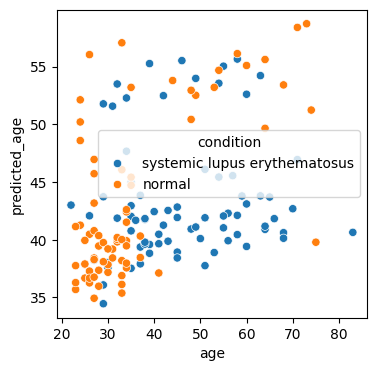

In [8]:
sns.scatterplot(data=df_all_bulk, x='age', y='predicted_age', hue='condition')

In [9]:
condition = 'normal'
for condition in ['normal', 'systemic lupus erythematosus']:
    df_p = df_all_bulk[df_all_bulk['condition'] == condition].copy()

    # Compute R² per cell type
    r2_per_ct = df_p.groupby("cell_type").apply(lambda g: spearmanr(g["age"], g["predicted_age"])[0]).to_dict()

    # Generate legend labels with R²
    legend_labels = {ct: f"{ct} (Goodness of fit={r2:.2f})" for ct, r2 in r2_per_ct.items()}
    print(condition, legend_labels)

normal {'CD8T': 'CD8T (Goodness of fit=0.48)'}
systemic lupus erythematosus {'CD8T': 'CD8T (Goodness of fit=0.16)'}


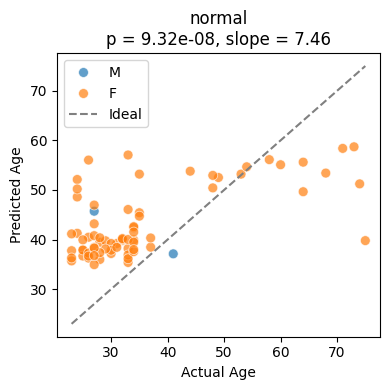

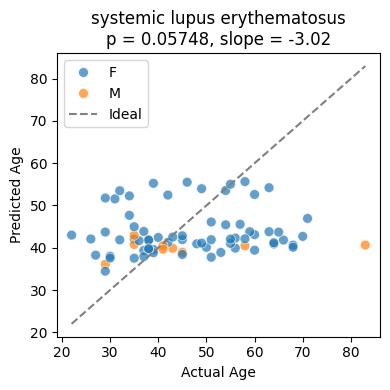

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

conds = ['normal', 'systemic lupus erythematosus']
for cond in conds:
    df_cond = df_all_bulk[df_all_bulk['condition'] == cond]
    age_diff = df_cond['predicted_age'] - df_cond['age']
    
    # One-sample t-test
    t_stat, p_value = stats.ttest_1samp(age_diff, 0)
    slope = age_diff.mean()
    
    # Plot
    plt.figure(figsize=(4, 4))
    sns.scatterplot(data=df_cond, x='age', y='predicted_age', s=50, alpha=0.7, hue='sex')
    
    # Identity line (perfect prediction)
    min_age, max_age = df_cond['age'].min(), df_cond['age'].max()
    plt.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

    plt.xlabel("Actual Age")
    plt.ylabel("Predicted Age")
    plt.title(f"{cond}\np = {p_value:.4g}, slope = {slope:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Drug analysis

In [17]:
df_all_bulk['condition'].unique()

array(['0 h Unstimulated', '24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI', '24 h RPMI + metformin',
       '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib',
       '24 h rhCXCL9', '24 h rhIFN-γ'], dtype=object)

Paired t-test: t=1.732, p=0.134
Mean difference (slope): 1.290


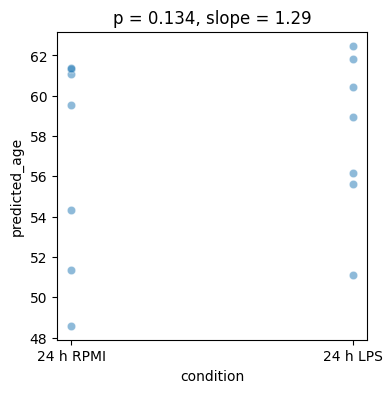

In [18]:
import scipy.stats as stats

ctr = '24 h RPMI'
treatment = '24 h LPS'

# Filter to the two conditions
df_subset = df_all_bulk[df_all_bulk['condition'].isin([ctr, treatment])]

# Ensure same donors are present in both conditions
df_pivot = (
    df_subset.pivot_table(index='donor_id', columns='condition', values='predicted_age')
    .dropna(subset=[ctr, treatment])
    .reset_index()
)

# Paired t-test
t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
print(f"Paired t-test: t={t_stat:.3f}, p={p_value:.4g}")

# Estimate slope (difference in means, since it's paired)
df_pivot["diff"] = df_pivot[treatment] - df_pivot[ctr]
slope = df_pivot["diff"].mean()
print(f"Mean difference (slope): {slope:.3f}")

# Plotting
df_melt = df_pivot.melt(id_vars='donor_id', value_vars=[ctr, treatment], var_name='condition', value_name='predicted_age')
sns.scatterplot(data=df_melt, x='condition', y='predicted_age', alpha=0.5)
plt.title(f"p = {p_value:.4g}, slope = {slope:.2f}")
plt.show()
# pearsonr(df['age'], df['predicted_age'])

In [19]:
import pandas as pd
import statsmodels.formula.api as smf

# Filter to relevant conditions
ctr = '24 h RPMI'
treatment = '24 h LPS'
df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()

# Ensure condition is a categorical variable
df_sub['condition'] = pd.Categorical(df_sub['condition'], categories=[ctr, treatment])

# Fit the mixed effects model
model = smf.mixedlm("predicted_age ~ condition", df_sub, groups=df_sub["donor_id"])
result = model.fit()

# Summary of the model
print(result.summary())

# Extract p-value and fixed effect estimate for treatment
p_value = result.pvalues[f"condition[T.{treatment}]"]
slope = result.params[f"condition[T.{treatment}]"]
print(f"Slope (effect of treatment): {slope:.3f}")
print(f"P-value: {p_value:.4g}")

             Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  predicted_age
No. Observations:    638      Method:              REML         
No. Groups:          7        Scale:               30.6050      
Min. group size:     57       Log-Likelihood:      -2008.1062   
Max. group size:     127      Converged:           Yes          
Mean group size:     91.1                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             56.496    1.654 34.166 0.000 53.255 59.737
condition[T.24 h LPS]  1.565    0.440  3.558 0.000  0.703  2.427
Group Var             18.441    1.968                           

Slope (effect of treatment): 1.565
P-value: 0.0003738


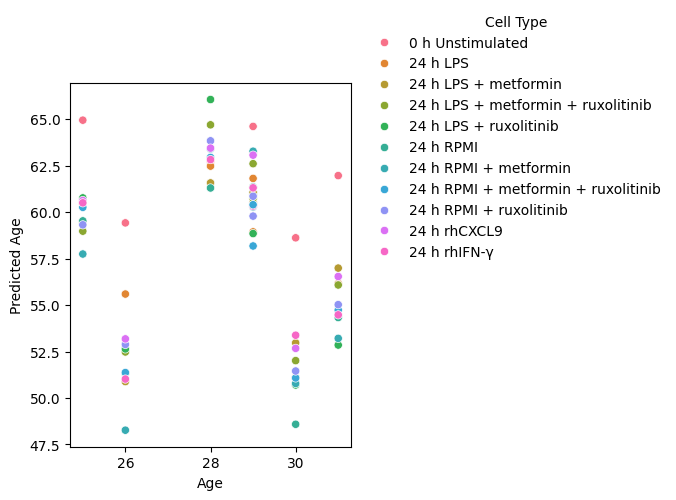

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Load data


# Aggregate predicted age per donor and cell type
cols = ['donor_id', 'age', 'cell_type']
if 'condition' in df.columns:
    cols.append('condition')
df_p = df.groupby(cols)['predicted_age'].median().reset_index()

# Compute R² per cell type
r2_per_ct = df_p.groupby("cell_type").apply(lambda g: spearmanr(g["age"], g["predicted_age"])[0]).to_dict()

# Generate legend labels with R²
legend_labels = {ct: f"{ct} (R²={r2:.2f})" for ct, r2 in r2_per_ct.items()}
df_p["cell_type_label"] = df_p["cell_type"].map(legend_labels)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
sns.scatterplot(data=df_p, x="age", y="predicted_age", hue='condition', ax=ax)

plt.xlabel('Age')
plt.ylabel('Predicted Age')
ax.legend(loc=(1.05, 0.5), fontsize=10, frameon=False, title="Cell Type")
ax.margins(x=0.05, y=0.05)
plt.tight_layout()
plt.show()

# Create Pseudocell

In [10]:
def assign_metacells(df, groupby_col, metacell_size=15):
    df = df.copy()
    metacell_id = np.empty(len(df), dtype=object)

    # Create a Series of indices to preserve order
    for group in df[groupby_col].unique():
        mask = df[groupby_col] == group
        idx = np.flatnonzero(mask)
        n_metacells = int(np.ceil(len(idx) / metacell_size))
        ids = np.repeat([f"{group}_MC{i}" for i in range(n_metacells)], metacell_size)[:len(idx)]
        metacell_id[idx] = ids

    df['metacell_id'] = metacell_id
    return df

def normalize(adata):
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    return adata
def create_metacell(adata, sum_by_col):
    from task_grn_inference.src.utils.util import sum_by
    adata.obs[sum_by_col] = adata.obs[sum_by_col].astype('category')
    print(adata.obs[sum_by_col].nunique())
    adata_bulk = sum_by(adata, sum_by_col, unique_mapping=True)
    adata_bulk = normalize(adata_bulk)

    # merge the remaining metadata
    adata_bulk.obs['__original_index__'] = adata_bulk.obs.index
    merged_obs = adata_bulk.obs.merge(
        adata.obs,
        on=sum_by_col,
        how='left',
        suffixes=('', '_from_single')
    )
    merged_obs = merged_obs.drop_duplicates(subset=sum_by_col, keep='last')
    merged_obs = merged_obs.set_index('__original_index__').loc[adata_bulk.obs.index]
    adata_bulk.obs = merged_obs
    return adata_bulk

In [2]:
dataset = 'data12' #CXCL9 

In [72]:
def main_metacell(dataset):
    # - read the data
    adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad')
    adata = adata[ ~adata.obs.isna().any(axis=1), :]
    # - group by before metacells
    cols = ['cell_type', 'dataset', 'donor_id', 'age', 'treatment']
    available_cols = [col for col in cols if col in adata.obs.columns]
    adata.obs['groupby_col'] = adata.obs[available_cols].astype(str).agg('_'.join, axis=1)

    # - assign metacells
    adata.obs = assign_metacells(adata.obs, groupby_col='groupby_col', metacell_size=15)
    adata.obs.head()[['groupby_col', 'metacell_id']]

    # - create metacells
    adata_metacell = create_metacell(adata, sum_by_col='metacell_id')

    # - save
    cols = ['dataset', 'sex', 'donor_id', 'age', 'cell_type']
    if 'treatment' in adata_metacell.obs.columns:
        cols.append('treatment')
    if 'disease' in adata_metacell.obs.columns:
        cols.append('disease')
    adata_metacell.obs = adata_metacell.obs[cols]
    print(adata_metacell.shape)
    adata_metacell.write(f'/vol/projects/jnourisa/datasets/{dataset}_metacell.h5ad')
for dataset in ['SLE_Asian', 'data7_allTPs_jalil', 'data13_Korean' , 'data13_Japanese']:
    print(dataset)
    main_metacell(dataset)

SLE_Asian
33375
(33375, 15893)
data7_allTPs_jalil
127218
(127218, 24516)
data13_Korean
23882
(23882, 20536)
data13_Japanese
19104
(19104, 19613)


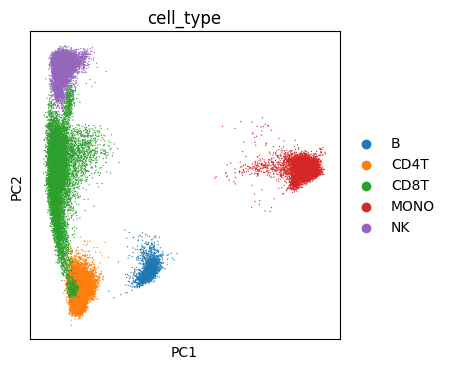

In [9]:
sc.pp.highly_variable_genes(adata_metacell, n_top_genes=2000, subset=True)
sc.pp.neighbors(adata_metacell)
sc.tl.umap(adata_metacell)
sc.pl.pca(adata_metacell, color=['cell_type'])

# Drug perturbation

In [2]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'LPS+Metformin',
    '24 h LPS + metformin + ruxolitinib': 'LPS+Met.+Rux.', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Metformin',
    '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met.+Rux.',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux.',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}

## Run association of TFs with perturbations


In [6]:
from ciim.src.tf_activity.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition
type = 'bulk'
test_type= 'mixed-effect' #'mixed-effect'
dataset = 'CXCL9'
feature_type= 'tf_activity' #'tf_activity' gene_expression


if False:
    if feature_type == 'tf_activity':
        wrapper_tf_activity(cell_types, datasets=[dataset], type=type)
    else:
        wrapper_gene_expression(cell_types, datasets=[dataset], type=type)

    par = {
            'type': type,
            'cell_type_resolution': 'Major_CT',
        }
    stats_all = wrapper_association_with_age_condition(par, cell_types, datasets=[dataset], feature_type=feature_type, features=None, test_type=test_type)
    stats_all.to_csv(f'../output/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')
else:
    stats_all = pd.read_csv(f'../output/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')
    

## Evaluate the known targets of drugs

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


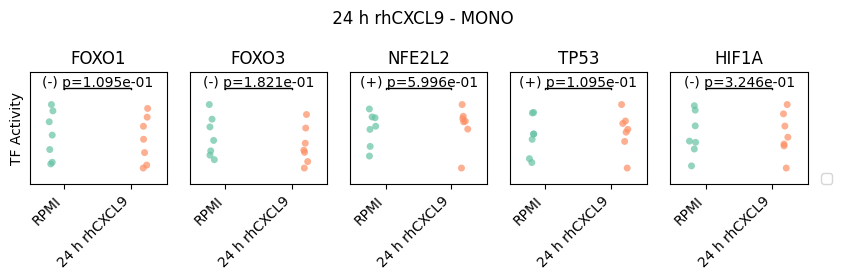

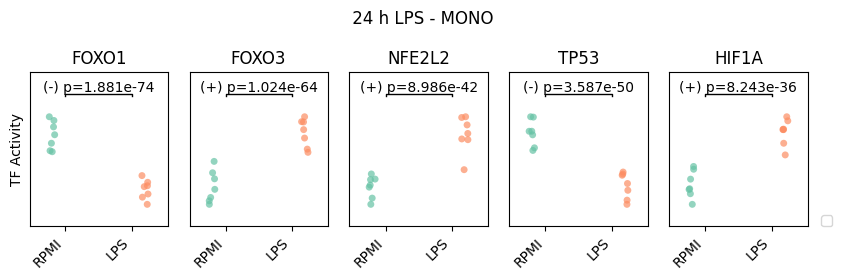

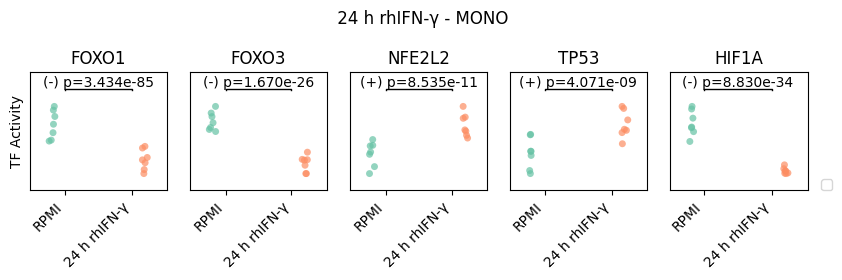

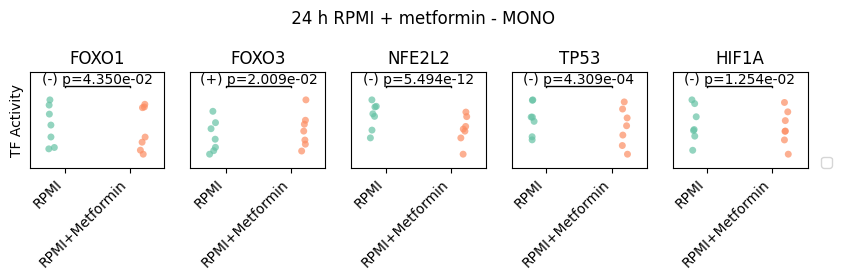

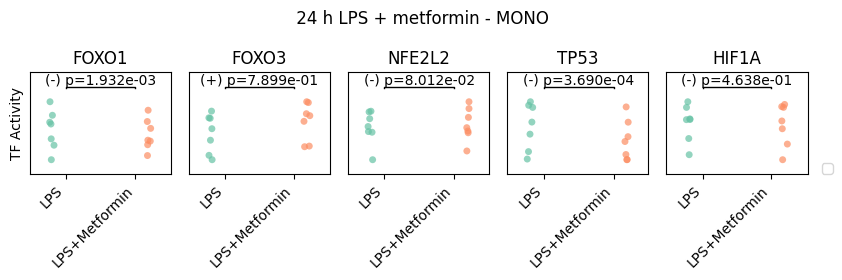

In [5]:
from ciim.src.tf_activity.plots import plot_ctr_condition_distribution

features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']

experiments = [('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h LPS', '24 h LPS + metformin'),
                ]
for ctr, treatment in experiments:
    plot_ctr_condition_distribution(['MONO'], features, treatment, ctr, dataset, type=type, feature_type=feature_type, 
                                    map_names=pretty_names, 
                                    stats=stats_all.rename(columns={'tf':'gene', 'target':'gene'}))



## Overall: perturbations vs RPMI and LPS

In [11]:
stats_1 = stats_all[(stats_all['ctrl']=='24 h RPMI') & (stats_all['condition'].isin(['24 h RPMI + metformin', '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib']))] 
stats_2 = stats_all[(stats_all['ctrl']=='24 h LPS') & (stats_all['condition'].isin(['24 h LPS + metformin', '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib']))] 
# stats_3 = stats_all[(stats_all['ctrl']=='24 h RPMI') & (stats_all['condition'].isin(['24 h LPS']))] 

stats_drugs = pd.concat([stats_1, stats_2], axis=0)
stats_drugs['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_drugs['slope_condition']]
ctrls = stats_drugs['ctrl'].unique()

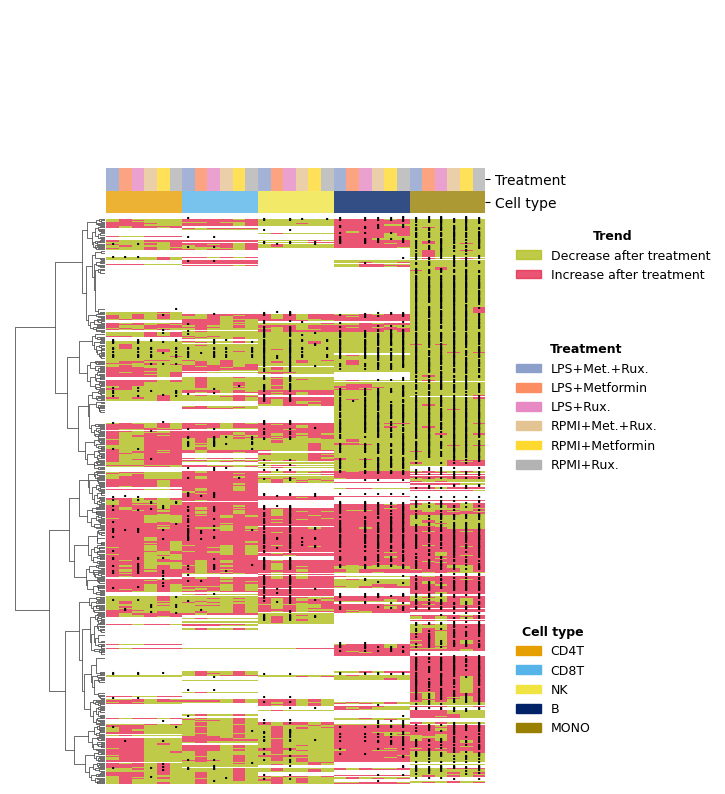

In [12]:
from ciim.src.tf_activity.plots import plot_overall_heatmap

stats_all_c = stats_drugs.copy()

stats_all_c['condition'] = stats_all_c['condition'].replace(pretty_names)
stats_all_c = stats_all_c[~stats_all_c['condition'].isna()]
stats_all_c = stats_all_c.rename(columns={'slope_condition': 'slope'})

stats_all_c['cell_type'] = pd.Categorical(stats_all_c['cell_type'], categories=cell_types, ordered=True)
stats_all_c['condition'] = stats_all_c['condition'].astype('category')

# stats_all_c['condition'] = pd.Categorical(stats_all_c['condition'], categories=pretty_names.values(), ordered=True)
stats_all_c['is_significant'] = stats_all_c['p_value_adj'] < 0.05
stats_all_c.rename(columns={'target': 'tf'}, inplace=True)
plot_overall_heatmap(stats_all_c, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='condition', second_col_palette={value: color for value, color in zip(pretty_names.values(), sns.color_palette("Set2", n_colors=len(pretty_names.values())) )},
                    trend_colors = ['#B0BF1A', '#E52B50'],
                    trend_names = ['Decrease after treatment', 'Increase after treatment'],
                    bbox_to_anchor=(1.05, 1),
                    bbox_to_anchor_col1=(1.05, .3),
                    bbox_to_anchor_col2=(1.05, .8),
                    figsize=(6, 10),
                    map_names={**{'cell_type':'Cell type', 'condition': 'Treatment'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

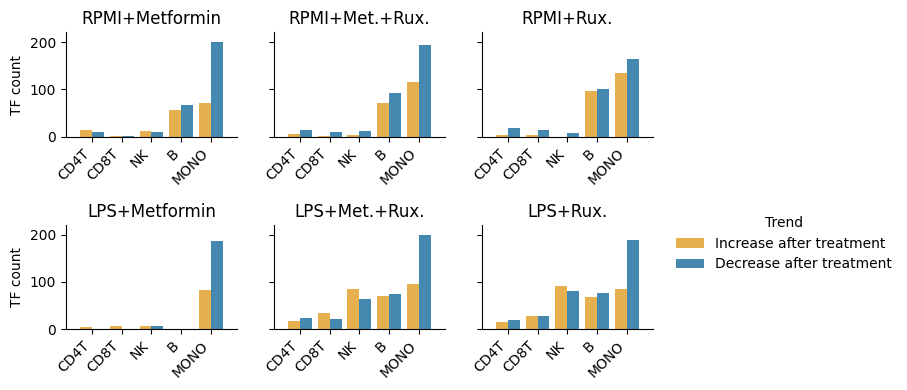

In [13]:
from ciim.src.tf_activity.plots import plot_sig_tfs_stats

fig, axes = plt.subplots(2, 3, figsize=(9, 4), sharey=True, sharex=False)

j = 0
for ctrl in ctrls:
    i = 0
    for treatment in stats_drugs['condition'].unique():
        stats = stats_drugs[(stats_drugs['ctrl'] == ctrl) & (stats_drugs['condition'] == treatment)  & (stats_drugs['p_value_adj']<0.05)]
        if len(stats) == 0:
            continue
        ax = axes[j, i]
        i += 1
        
        stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
        plot_sig_tfs_stats(stats, figsize=(5, 2), palette=palette_treatment, ax=ax)
        ax.get_legend().remove()
        ax.set_title(f'{pretty_names[treatment] }')
    
    j += 1
ax.legend(loc=(1.1, 0.5), title='Trend', frameon=False)

## Pathway analysis

In [18]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper

pathway_scores_store = []
for ctr in stats_drugs['ctrl'].unique():
    for treatment in stats_drugs['condition'].unique():
            
        stats_sig = stats_drugs[(stats_drugs['ctrl'] == ctr) & (stats_drugs['condition'] == treatment) & (stats_drugs['p_value_adj'] < 0.05)]
        if len(stats_sig) == 0:
            continue

        pathway_scores = pathway_analysis_wrapper(stats_sig, pvalue_col='p_value_adj')
        if pathway_scores is None:
            continue
        pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["Adjusted P-value"])
        pathway_scores['ctrl'] = ctr
        pathway_scores['condition'] = treatment
        pathway_scores_store.append(pathway_scores)
pathway_scores_all = pd.concat(pathway_scores_store)

(4, 10)
(2, 10)
(9, 10)
(4, 10)
(4, 10)


KeyError: 'Adjusted P-value'

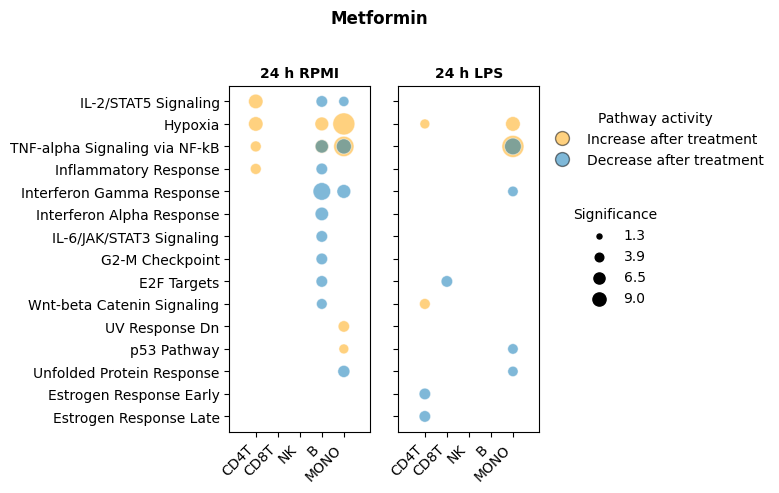

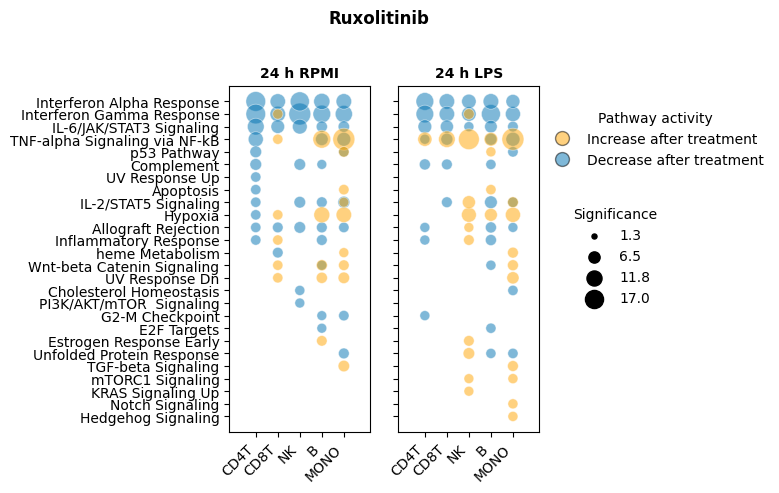

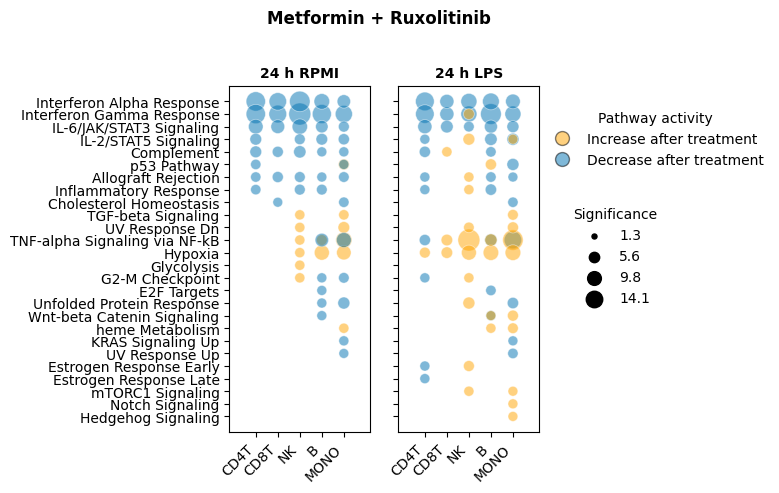

In [209]:
from ciim.src.tf_activity.plots import dotplot_category_color
def plot_pathways_enrichment(pathway_df, title=f'metformin'):
    ctrls = pathway_df['ctrl'].unique()
    fig, axes = plt.subplots(1, len(ctrls), figsize=(2*len(ctrls), 4.5), sharey=True, sharex=True)

    for i, ctrl in enumerate(ctrls):
        ax = axes[i] if len(ctrls)>1 else axes
        pathway_scores = pathway_df[pathway_df['ctrl']==ctrl]
        pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
        if i == len(ctrls)-1:
            show_color_legend = True
            show_size_legend = True
        else:
            show_color_legend = False
            show_size_legend = False
        dotplot_category_color(pathway_scores, 
                    ax, 
                    color_col='trend', 
                    size_col='neg_log10_adj_pval', 
                    x='cell_type', 
                    y='Term', 
                    sizes=(50, 250),
                    show_color_legend=show_color_legend, 
                    show_size_legend=show_size_legend,
                    size_legend_title='Significance',
                    color_legend_title='Pathway activity',
                    size_legend_loc=(1.2, 0.35),
                    color_legend_loc=(1.02, 0.75),
                    y_label='',
                    alpha=0.5,
                    palette=palette_treatment)
        ax.set_title(ctrl, fontsize=10, fontweight='bold')

    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.05)
plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['condition'].isin(['24 h RPMI + metformin', '24 h LPS + metformin'])], title=f'Metformin')

plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['condition'].isin(['24 h RPMI + ruxolitinib', '24 h LPS + ruxolitinib'])], title=f'Ruxolitinib')

plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['condition'].isin(['24 h RPMI + metformin + ruxolitinib', '24 h LPS + metformin + ruxolitinib'])], title=f'Metformin + Ruxolitinib')


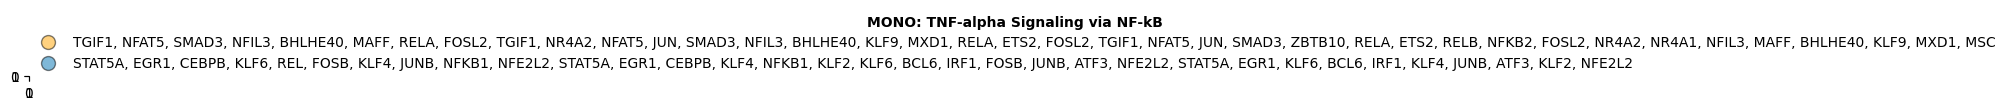

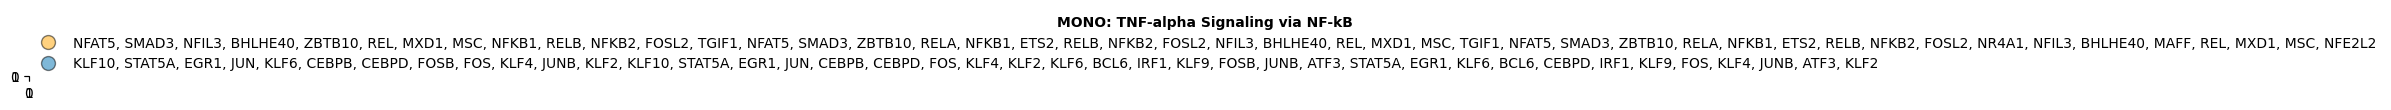

In [210]:
# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'MONO'

def explode_bifurcation_term(cell_type, term):
    pathway_scores_t = pathway_scores[
        (pathway_scores['Term'] == term) &
        (pathway_scores['cell_type'] == cell_type)
    ]
    
    if pathway_scores_t.empty:
        print(f"No data found for cell type '{cell_type}' and term '{term}'")
        return

    df = (
        pathway_scores_t
        .groupby('trend')['Genes']
        .apply(lambda x: ', '.join(x))
        .reset_index(name='Genes')
        .set_index('trend')
    )

    pp_dict = {}
    every_n_words = 5

    for trend in df.index:
        genes = df.loc[trend, 'Genes'].split(';')
        if trend == 'Increase in aging':
            wrapped = ', \n'.join(
                [', '.join(genes[i:i + every_n_words]) for i in range(0, len(genes), every_n_words)]
            )
        else:
            wrapped = ', '.join(genes)
        pp_dict[trend] = wrapped

    # Actual plot
    from matplotlib.lines import Line2D
    alpha = 0.5
    plt.figure(figsize=(0, 0))

    # Create legend handles only for present trends
    color_legend = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
               markersize=10, label=pp_dict[trend], alpha=alpha)
        for trend, color in palette_treatment.items()
        if trend in pp_dict
    ]

    legend = plt.legend(
        title=f'{cell_type}: {term}',
        title_fontsize=10,
        fontsize=10,
        handles=color_legend,
        loc=(1, .1),
        frameon=False
    )
    legend.get_title().set_fontweight('bold')
for ctr in ctrls:
    pathway_scores = pathway_scores_all[pathway_scores_all['ctrl']==ctr]
    explode_bifurcation_term(cell_type, term)


## Aging TFs: perturbation vs RPMI and LPS

In [11]:
# stats_drugs[(stats_drugs['cell_type'] == 'CD8T')& (stats_drugs['tf'] == 'EOMES') ].copy()
stats_all['condition'].unique()

array(['24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI + metformin', '24 h RPMI + metformin + ruxolitinib',
       '24 h RPMI + ruxolitinib', '24 h rhCXCL9', '24 h rhIFN-γ',
       '0 h Unstimulated'], dtype=object)

In [20]:
# stats_df = stats_all[(stats_all['ctrl']=='24 h RPMI') & (stats_all['condition'].isin(['24 h LPS', '24 h LPS + metformin', '24 h RPMI + metformin']))] 

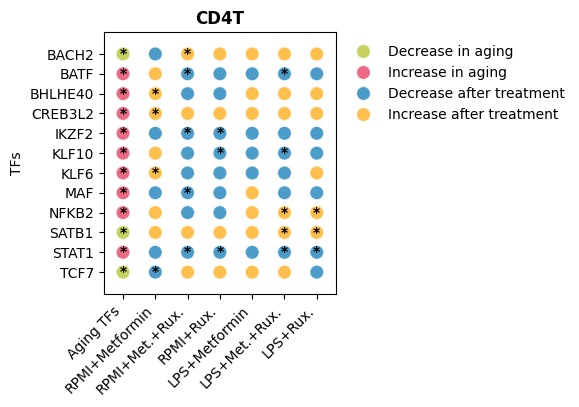

In [22]:
from ciim.src.common import palette_trend, palette_treatment
palette_all = {**palette_trend, **palette_treatment}
# stats_RPMI_ctr['dataset'] = stats_RPMI_ctr['dataset'].apply(lambda name: surrogate_names.get(name, name))
stats_df = stats_drugs.copy()


type = 'bulk'
race = 'both'

for cell_type in ['CD4T']:
    # - aging tfs
    stats_aging  = retrieve_sig_stats(type=type, race=race).drop_duplicates(subset=['tf', 'cell_type'])
    stats_aging = stats_aging[stats_aging['cell_type']==cell_type]
    stats_aging['analysis'] = 'Aging TFs'

    # - drugs
    stats_sotre = []
    for d in stats_df['condition'].unique():
        stats_d = stats_df[(stats_df['condition'] == d) & (stats_df['cell_type'] == cell_type)].copy()
        stats_d['is_significant'] = stats_d['p_value_adj'] < 0.05

        stats_d['analysis'] = d 
        stats_d['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_d['slope_condition']]
        stats_sotre.append(stats_d)
    stats_d = pd.concat(stats_sotre)
    # - subse the aging tfs to the drugs
    stats_d_sig = stats_d[stats_d['p_value_adj'] < 0.05]
    common_tfs = stats_d_sig['tf'].unique()
    stats_aging = stats_aging[stats_aging['tf'].isin(common_tfs)]

    
    # - merge
    df = pd.concat([stats_aging, stats_d])
    df['neg_log10_adj_pval'] = -np.log10(df['p_value_adj'])
    # - subset the tfs
    if False:
        selected_tfs = stats_aging.sort_values('meta_p_adj').head(30)['tf'].unique() # change this to centrality
        
    else:
        selected_tfs = stats_aging['tf'].unique()
    df = df[df['tf'].isin(selected_tfs)]
    
    

    fig, ax = plt.subplots(1, 1, figsize=(3,len(selected_tfs)*.2 + 1))
    df['analysis'] = df['analysis'].apply(lambda name: pretty_names.get(name, name))
    sns.scatterplot(data=df, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, 
                    s=100 , 
                    # sizes=(50, 100), 
                    alpha=.7)
    ax.margins(x=.1, y=.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.set_ylabel('TFs')
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    # Add significance annotation (e.g., a dot or asterisk) to significant points
    for _, row in df.iterrows():
        if row.get('is_significant', False):  # Ensure this column exists
            ax.text(
                x=row['analysis'],
                y=row['tf'],
                s='*',  # or '.' or '★'
                color='black',
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold'
            )
    plt.title(f'{cell_type}', fontsize=12, fontweight='bold')

# Linearity analysis

In [213]:
adata_dict = {dataset:retrieve_adata_bulk(dataset) for dataset in datasets_all}

In [214]:
# - calculate corr
corr_results = {}
exp_results = {}
for cell_type in cell_types:
    exp_results[cell_type] = {}
    corr_results[cell_type] = {}
    for dataset in datasets_all:

        # - choose if gene expression or TF activity
        if False:
            adata = adata_dict[dataset]
            adata = adata[adata.obs['cell_type'] == cell_type].copy()
            adata.X = adata.X.todense()
        else:
            adata = retrieve_feature_data(dataset, cell_type, type='bulk')

        if adata.shape[0] < 2:
            continue

        expr_df = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var_names)
        expr_df['age'] = adata.obs['age']
        expr_df = expr_df[(expr_df['age'] > 30) & (expr_df['age'] < 75)].copy()  # Filter out age ranges
        if True:
            expr_df['age_bin'] = (expr_df['age'].astype(int) // 5) * 5
            expr_df = expr_df.groupby('age_bin').mean().drop(columns='age').sort_index()
        else:
            expr_df = expr_df.set_index('age').sort_index()
        if expr_df.shape[0] < 2:
            continue

        corr = expr_df.T.corr(method='spearman')  # Correlation between age bins
        corr_results[cell_type][dataset] = corr
        exp_results[cell_type][dataset] = expr_df

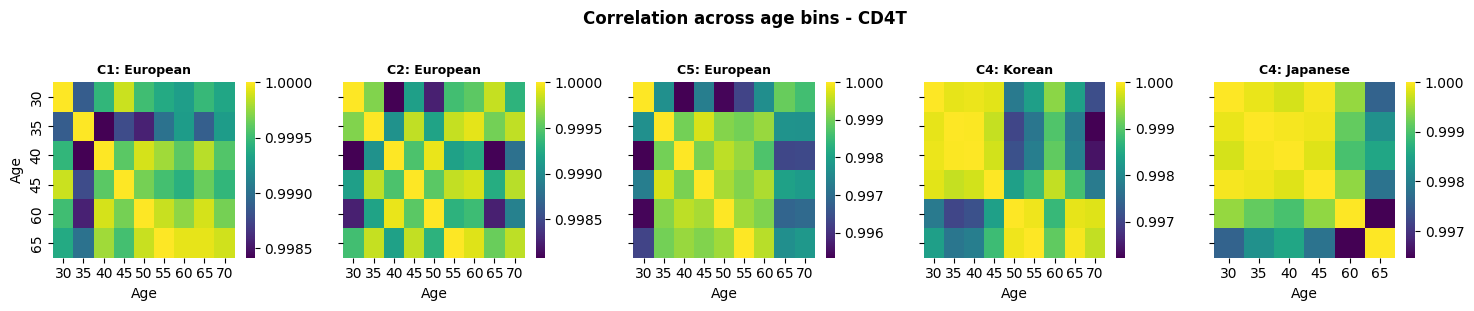

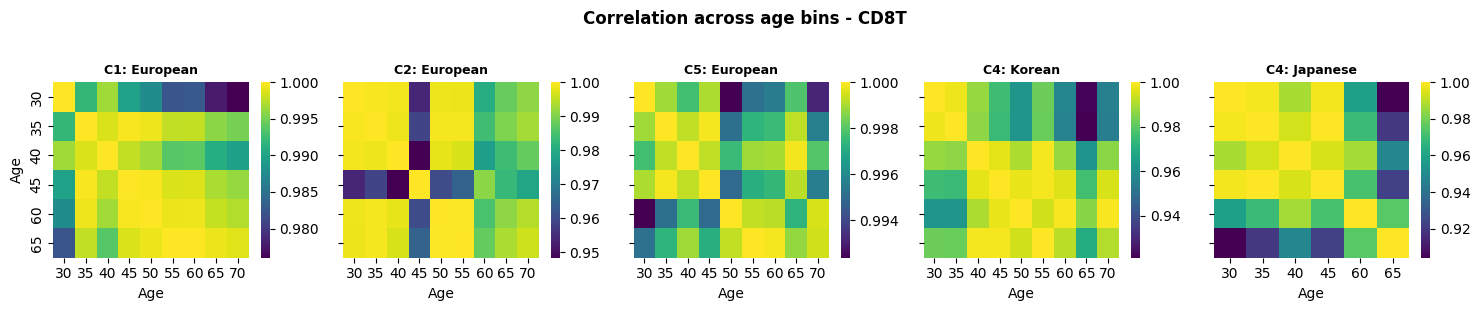

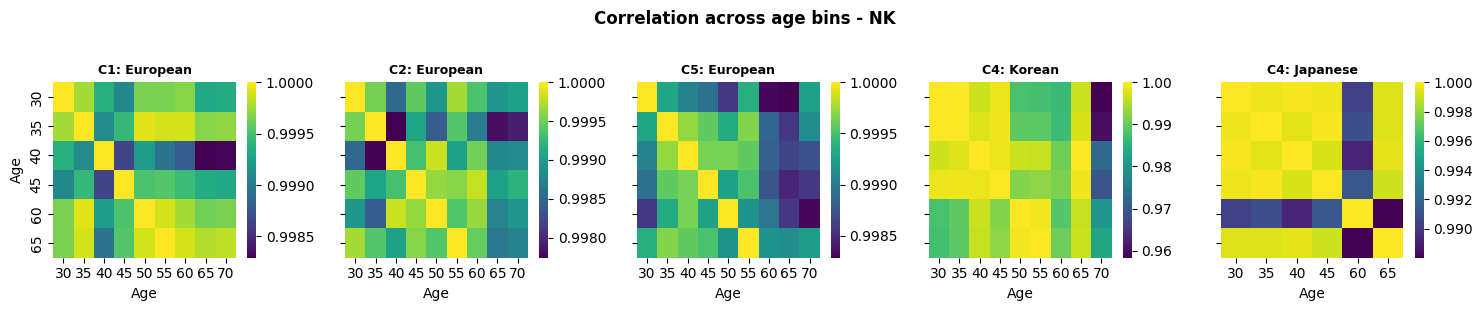

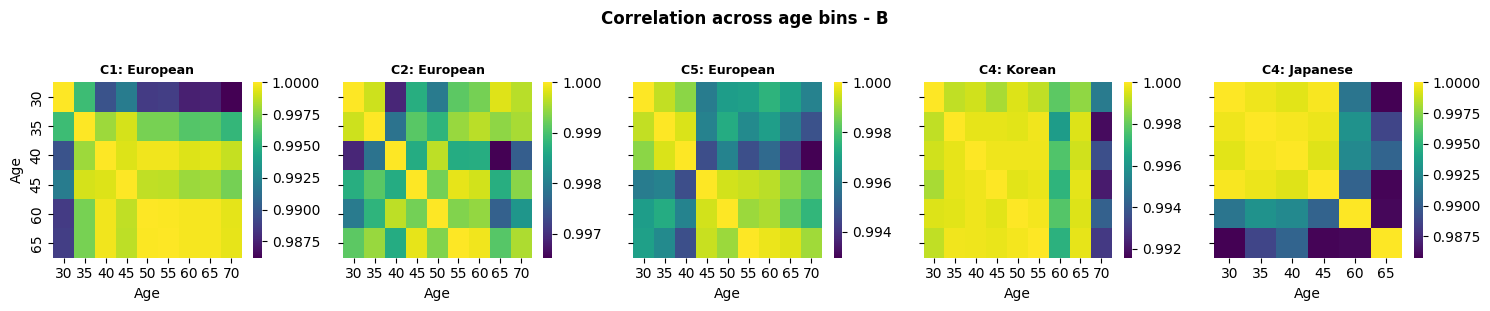

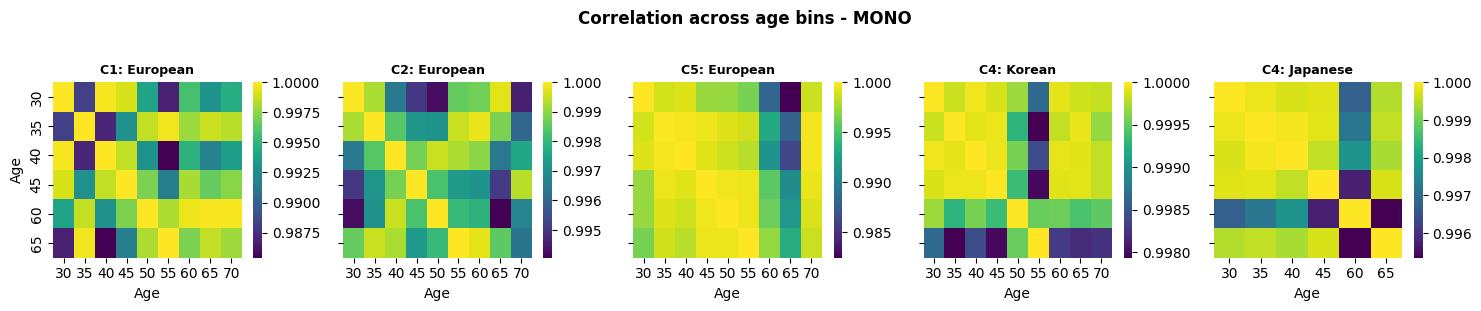

In [215]:
for cell_type, dataset_corrs in corr_results.items():
    datasets = [dataset for dataset in datasets_all if dataset!='data12']
    if not datasets:
        continue
    n_cols = len(datasets)
    n_rows = 1
    fig, axes = plt.subplots(1, len(datasets), figsize=(3 * n_cols, 3), sharey=True)
    fig.suptitle(f'Correlation across age bins - {cell_type}', fontsize=12, fontweight='bold', y=1.02)
    for i, dataset in enumerate(datasets):
        corr = dataset_corrs[dataset]
        ax = axes[i]
        
        sns.heatmap(corr, ax=ax, cmap='viridis')
        # sns.clustermap(corr, method='ward')
        ax.set_title(surrogate_names[dataset], fontsize=9, fontweight='bold')
        ax.set_xlabel('Age')
        if i == 0:
            ax.set_ylabel('Age')
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    plt.show()

# Pseudo trajectory

In [216]:
from ciim.src.tf_activity.helper import run_pseudotime_analysis
sig_nets_bulk = pd.read_csv('../output/tf_activity/sig_nets_bulk.csv')

ImportError: cannot import name 'run_pseudotime_analysis' from 'ciim.src.tf_activity.helper' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/helper.py)

In [5]:
adata_dict = {}
for sub_type in ['Tcm_Naive_CD8', 'Tcm_Naive_CD4']:
    major_cell_type = mapping_minor_2_major[sub_type]
    adata_dict[sub_type] = {}
    for dataset in ['data1', 'data13']:
        adata = retrieve_feature_data(dataset, major_cell_type, type='bulk_minor')
        adata = adata[adata.obs['Sub_CT'] == sub_type].copy()
        net_sig = sig_nets_bulk[sig_nets_bulk['cell_type'] == major_cell_type] # - subset to only sig TFs
        adata = adata[:, adata.var_names.isin(net_sig['source'].unique())] 
        adata = run_pseudotime_analysis(adata)

        adata_dict[sub_type][dataset] = adata
        

Tcm_Naive_CD8 data1 SignificanceResult(statistic=0.15035098691069618, pvalue=5.424397466974495e-06)


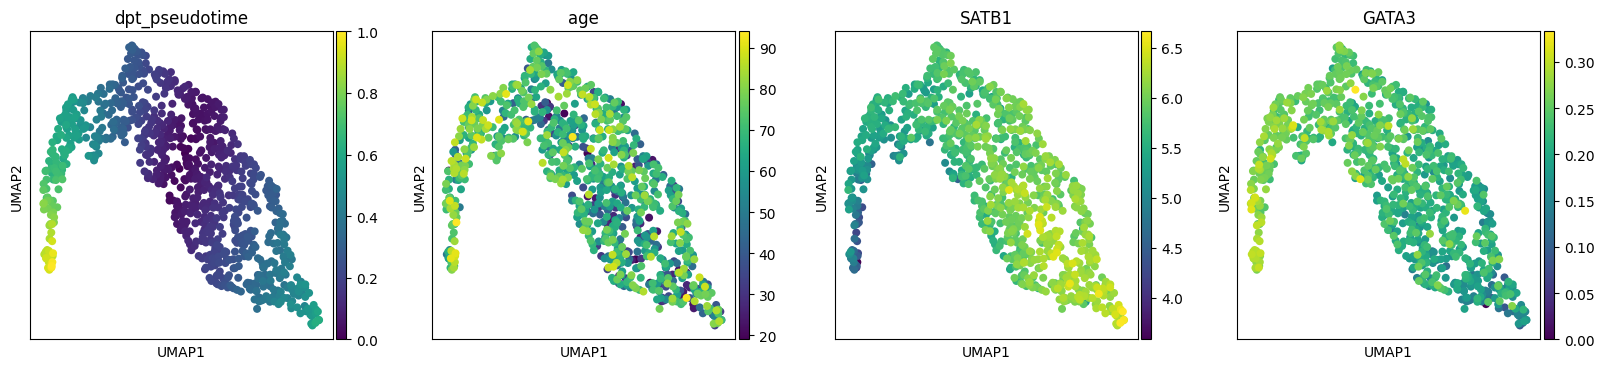

In [6]:
sub_type = 'Tcm_Naive_CD8'
dataset = 'data1'
adata = adata_dict[sub_type][dataset].copy()
print(sub_type, dataset, spearmanr(adata.obs['dpt_pseudotime'], adata.obs['age']))

# adata.obs.drop(columns='SATB1', inplace=True)
sc.pl.umap(adata, color=['dpt_pseudotime', 'age', 'SATB1', 'GATA3'])

computing velocity graph (using 1/56 cores)


  0%|          | 0/907 [00:00<?, ?cells/s]

Traceback (most recent call last):
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/managers.py", line 599, in _run_server
    server.serve_forever()
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/managers.py", line 184, in serve_forever
    sys.exit(0)
SystemExit: 0

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  Fi

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


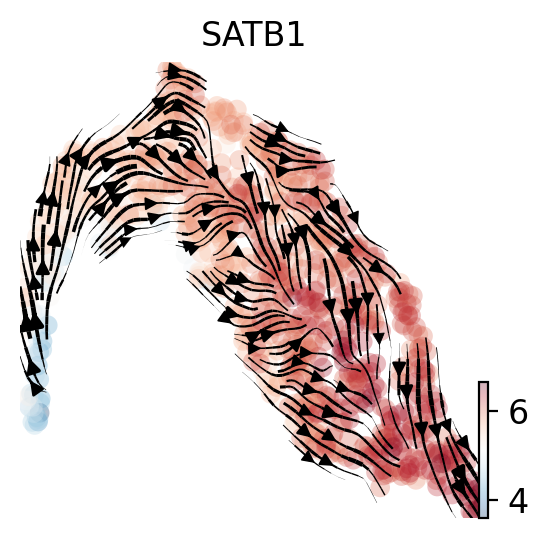

In [7]:
import scvelo as scv
import numpy as np
gene = 'SATB1'

scv.settings.set_figure_params('scvelo')

# Ensure neighbors are computed
adata.layers['spliced'] = adata.X.copy()  # Or use 'lognorm' layer if you prefer
sc.pp.neighbors(adata)

# Set UMAP if not already done
if 'X_umap' not in adata.obsm:
    sc.tl.umap(adata)

# Add the expression to a fake velocity layer
adata.layers['velocity'] = np.zeros_like(adata.X)
gene_idx = adata.var_names.get_loc(gene)
adata.layers['velocity'][:, gene_idx] = adata[:, gene].X.toarray().flatten() \
    if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()

# Optional: for coloring
adata.obs[gene] = adata[:, gene].X.toarray().flatten() \
    if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()

# Compute the fake embedding (required by scvelo)
scv.tl.velocity_graph(adata)

# Now you can plot
scv.pl.velocity_embedding_stream(adata, basis='umap', color=gene, size=200, figsize=(3,3),
    # , colorbar=False,
    legend_loc=(1.5, .2)
)

# In silico prediction

In [2]:
type = 'bulk' 
race = 'european'
cell_type = 'CD8T'
min_degree = 3 # shared edges in nets
alpha = .1 # ratio of the whole change to be applied in the simulation alpha*max_delta
n_iter = 10
age_range = [20, 75]
# net = retrieve_net(dataset, cell_type)[['source', 'target', 'weight']]
if race == 'european':
    datasets = datasets_e
else:
    datasets = datasets_a

In [102]:
def prepare_inputs(type, race, dataset, cell_type, min_degree, age_range=[20, 75]):
    from ciim.src.tf_activity.helper import get_consensus_net

    # - read inputs
    if False:
        stats_targets = pd.read_csv(f'../output/gene_expression/stats_all_{type}.csv')
        stats_sig = retrieve_sig_stats(type, race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
        stats_sig_target = stats_targets[(stats_targets['analysis'] == race) & (stats_targets['meta_p_adj'] < 0.05) & (stats_targets['trend']!= 'Inconsistent')].drop_duplicates(subset=['cell_type', 'target'])

        sig_tfs = stats_sig['tf'].unique()

        # - prepare the net
        sig_targets = stats_sig_target['target'].unique()
        net = get_consensus_net(datasets_e, cell_type, min_degree)
        net = net[net['source'].isin(sig_tfs)]
        net = net[net['target'].isin(sig_targets)]
        print(np.setdiff1d(stats_sig['tf'].unique(), net['source'].unique()))
    else: #TODO: choose this based on the simulation aims. -> the sig net could be either promotr based on not
        if False: # - use the sig net
            net = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')
        else:
            net = get_consensus_net(datasets_all, cell_type, min_degree)
        net = net[net['cell_type'] == cell_type].copy()
    
    # - convert net to a matrix (gene x tf)
    net_matrix_df = net.pivot(index='target', columns='source', values='weight').fillna(0)
    print(net_matrix_df.shape)

    # - prepare the expression data
    adata = retrieve_adata_bulk(dataset, type=type)
    adata = adata[~adata.obs['age'].isna()].copy()
    adata.obs['age'] = adata.obs['age'].astype(int)
    adata = adata[adata.obs['cell_type'] == cell_type].copy()

    # - bin 5 years and take the mean of the expression values
    expr_df = pd.DataFrame(adata.X.todense(), index=adata.obs.index, columns=adata.var_names)
    expr_df['age'] = adata.obs['age']
    expr_df = expr_df[(expr_df['age'] > age_range[0]) & (expr_df['age'] < age_range[1])].copy()  # Filter out age ranges
    expr_df['age_bin'] = (expr_df['age'].astype(int) // 5) * 5
    expr_df = expr_df.groupby('age_bin').mean().drop(columns='age')

    # - keep only those genes which are in both
    # if False:
    common_genes = net_matrix_df.index.intersection(expr_df.columns)
    net_matrix_df = net_matrix_df.loc[common_genes]
    expr_df = expr_df[common_genes]

    # - define variables for the simulation
    max_delta = (expr_df.max() - expr_df.min()).values

    return net_matrix_df, expr_df, max_delta
# - run simulation
def run_simulation(N, X0, p, n_iter=10):
    X = X0.copy()
    X_store = []
    for it in range(n_iter):
        X = X + np.dot(N, p)
        X_store.append(X)
    Xs = np.array(X_store)
    return Xs
def prepare_p(net_matrix_df, perturb_tfs, max_delta):
    '''Gets tf names and create a p vector with the same column as N, where the given tfs are set to given values'''
    all_tfs = net_matrix_df.columns
    p = np.zeros_like(all_tfs, dtype=float)
    missing_tfs = [tf for tf in perturb_tfs if tf not in all_tfs]
    if missing_tfs:
        print("Missing TFs:", missing_tfs)
        perturb_tfs = [tf for tf in perturb_tfs if tf in all_tfs]  # filter only valid ones

    idxs = [np.where(all_tfs == tf)[0][0] for tf in perturb_tfs]
    for idx in idxs:
        p[idx] = max_delta[idx]  # or scale this as you like
    return p

def combinatorial_experiments(net_matrix_df, expr_df, max_delta, perturb_tfs=None, combinations=[1, 2], n_iter=10):
    import itertools
    all_tfs = net_matrix_df.columns
    N = net_matrix_df.values
    X0 = expr_df.iloc[0, :].values
    if perturb_tfs is None:
        perturb_tfs = all_tfs
    perturb_tfs = np.asarray(perturb_tfs)
    results = []
    # loop over single and pairwise TF combinations
    for k in combinations:  # 1 = single, 2 = pairs
        for perturb_tfs_i in itertools.combinations(perturb_tfs, k):
            p = prepare_p(net_matrix_df, perturb_tfs_i, max_delta)
            # run the simulation
            Xs = run_simulation(N, X0, p, n_iter=n_iter)
            X = Xs[-1]

            # measure impact
            rho, _ = spearmanr(X0, X)
            impact = 1 - rho  # higher = more change

            results.append({
                'tf': perturb_tfs_i if k > 1 else perturb_tfs_i[0],
                'impact': impact,
                'num_TFs': k
            })
    # convert to DataFrame
    impact_df = pd.DataFrame(results)
    return impact_df


## Simulated pattern vs real

In [104]:
from ciim.src.tf_activity.helper import retrieve_sig_stats
# - test run
dataset = datasets_e[1]
net_matrix_df, expr_df, max_delta = prepare_inputs(type=type, race=race, dataset=dataset, cell_type=cell_type, min_degree=min_degree)

# - sig stats
stats_sig = retrieve_sig_stats(type='bulk', race='european', filter_inconsistent=True)
stats_sig = stats_sig[stats_sig['cell_type'] == cell_type]
perturb_tfs = stats_sig['tf'].unique()
n_iter = len(expr_df.index)
predict_expr = run_simulation(net_matrix_df.values, expr_df.iloc[0, :].values, prepare_p(net_matrix_df, perturb_tfs, max_delta*alpha), n_iter=n_iter)
predict_expr_df = pd.DataFrame(predict_expr, columns=expr_df.columns, index=expr_df.index)

(2456, 280)
Missing TFs: ['SP110']


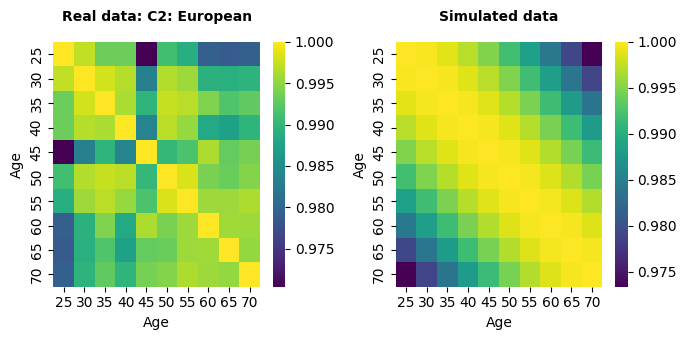

In [105]:
corr_o = expr_df.T.corr()
corr_s = predict_expr_df.T.corr()
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharey=False)
ax = axes[0]
sns.heatmap(corr_o, ax=ax, cmap='viridis')
ax.set_title(f'Real data: {surrogate_names[dataset]}', fontsize=10, fontweight='bold', pad=15)
ax.set_xlabel('Age')
ax.set_ylabel('Age')
ax = axes[1]
sns.heatmap(corr_s, ax=ax, cmap='viridis')
ax.set_title(f'Simulated data', fontsize=10, fontweight='bold', pad=15)
ax.set_xlabel('Age')
ax.set_ylabel('Age')
plt.tight_layout()
# .style.background_gradient(cmap='viridis', low=0, high=1, axis=1)

In [109]:
from ciim.src.clock.helper import predict_age

adata_real = ad.AnnData(X=expr_df.values, obs=expr_df.index.to_frame(index=False), var=pd.DataFrame(index=expr_df.columns))
adata_pred = ad.AnnData(X=predict_expr_df.values, obs=predict_expr_df.index.to_frame(index=False), var=pd.DataFrame(index=predict_expr_df.columns))

adata_real.obs['cell_type'] = cell_type
predict_age(adata_real, cell_type)

array([67.50051581, 70.56071501, 72.57685649, 71.48251472, 80.31104508,
       76.65829726, 79.33516852, 82.7600827 , 84.13974688, 86.10583873])

## combinatorial experiments

In [52]:
# - run combinatorial experiments
impact_df_store = []
for dataset in datasets:
    net_matrix_df, expr_df, max_delta = prepare_inputs(type=type, race=race, dataset=dataset, cell_type=cell_type, min_degree=min_degree)
    impact_df = combinatorial_experiments(net_matrix_df, expr_df, max_delta, combinations=[1], n_iter=n_iter)
    impact_df = impact_df.sort_values('impact', ascending=False)
    # impact_df['impact'] = impact_df['impact']/impact_df['impact'].max()
    impact_df['dataset'] = dataset
    impact_df_store.append(impact_df)
impact_df = pd.concat(impact_df_store)

(589, 102)
(589, 102)
(589, 102)


Text(0.5, 1.0, 'Asian-CD8T')

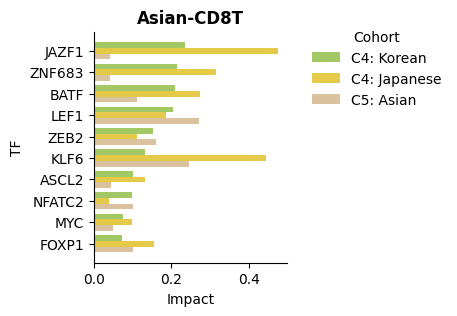

In [53]:
# - subset to top tfs
top_tfs = impact_df.groupby('tf').agg({'impact': 'mean'}).sort_values('impact', ascending=False).head(10).index
impact_df_sub = impact_df[impact_df['tf'].isin(top_tfs)]
# - plot
impact_df_sub['dataset'] = impact_df_sub['dataset'].map(surrogate_names)
fig, ax = plt.subplots(figsize=(2.5, 3))
sns.barplot(data=impact_df_sub, hue='dataset', y='tf', x='impact', alpha=1, palette=palette_datasets_pretty, dodge=True, ax=ax)
ax.set_xlabel('Impact')
ax.set_ylabel('TF')
ax.margins(x=0.05, y=0.05)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc=(1.1, .65), frameon=False, title='Cohort', fontsize=10)
ax.set_title(f'{surrogate_names[race]}-{cell_type}', fontsize=12, fontweight='bold')

In [45]:
# - check the corr between age groups
expr_df.T.corr().style.background_gradient(cmap='viridis', low=0, high=1, axis=1)

age_bin,20,25,30,35,40,45,50,55,60,65,70
age_bin,,,,,,,,,,,
20,1.000000,0.996428,0.996723,0.992152,0.982596,0.988149,0.971207,0.972447,0.971436,0.982432,0.964672
25,0.996428,1.000000,0.998005,0.994229,0.987590,0.989393,0.977543,0.979394,0.978019,0.987008,0.970507
30,0.996723,0.998005,1.000000,0.996814,0.990728,0.993209,0.982148,0.984012,0.982220,0.990686,0.975635
35,0.992152,0.994229,0.996814,1.000000,0.995514,0.997174,0.990156,0.990813,0.989731,0.995134,0.984850
40,0.982596,0.987590,0.990728,0.995514,1.000000,0.995817,0.995638,0.996071,0.995326,0.996518,0.992197
45,0.988149,0.989393,0.993209,0.997174,0.995817,1.000000,0.992141,0.991815,0.990737,0.994696,0.987817
50,0.971207,0.977543,0.982148,0.990156,0.995638,0.992141,1.000000,0.997362,0.996595,0.994715,0.995858
55,0.972447,0.979394,0.984012,0.990813,0.996071,0.991815,0.997362,1.000000,0.996763,0.995218,0.994203
60,0.971436,0.978019,0.982220,0.989731,0.995326,0.990737,0.996595,0.996763,1.000000,0.994561,0.994269


In [46]:
if False:
    # - create perturbation
    tf_case = 'BATF' # 'LEF1'
    tf_idx = np.where(tfs == tf_case)[0][0]
    p = np.zeros_like(tfs, dtype=float)  # or same shape as tfs
    p[tf_idx] = max_delta[tf_idx]

    
    X = run_simulation(N, X0, p, n_iter=10)

    # - evaluate the change 
    from scipy.stats import spearmanr
    from scipy.stats import pearsonr
    # print(f'Spearman (initial vs end X)', spearmanr(X0, X_end))
    print(f'Spearman (prediction vs initial X)', spearmanr(X0, X))
    # print(f'Spearman (prediction vs end X)', spearmanr(X_end, X))

# Disease

In [54]:
type = 'bulk'
stats_sig = retrieve_sig_stats(type).drop_duplicates(subset=['cell_type', 'tf'])
selected_cell_types = ['NK', 'CD8T', 'CD4T']

def retrieve_sle(type):
    dataset = 'SLE'
    stats_tfs = pd.read_csv(f'../output/tf_activity/stats_features_{type}.csv')
    stats_sle = stats_tfs[stats_tfs['dataset'].str.contains(dataset)].copy()
    stats_sle = stats_sle[stats_sle['p_value_adj'] < 0.05].copy()
    return stats_sle
stats_sle = retrieve_sle('bulk')

In [55]:
# Convert the entire column to arrays
stats_sle.groupby('cell_type').size().sort_values(ascending=False)

cell_type
CD8T    471
CD4T    292
MONO    225
B       193
NK      159
dtype: int64

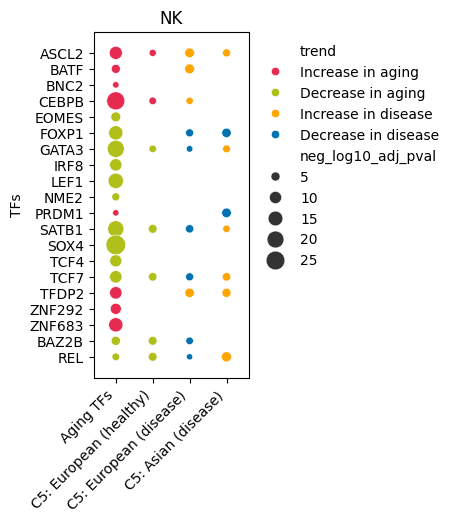

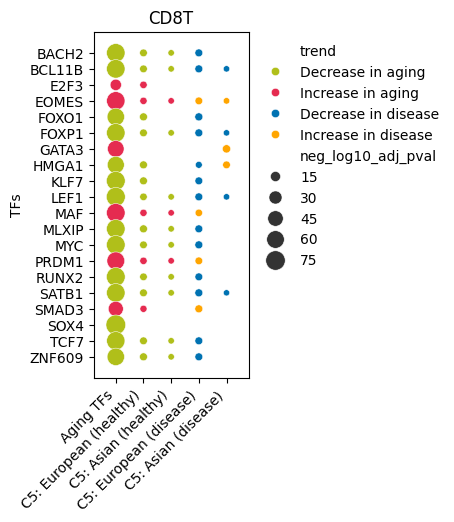

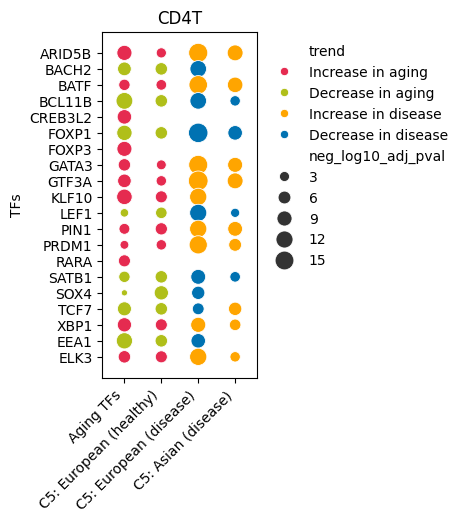

In [61]:
from ciim.src.common import palette_trend, palette_disease_effect
palette_all = {**palette_trend, **palette_disease_effect}
stats_sle['dataset'] = stats_sle['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in selected_cell_types:

    # - validation
    validation_df = stats_sig[stats_sig['cell_type']==cell_type]
    validation_df['analysis'] = 'Aging TFs'
    top_tfs = validation_df.sort_values('meta_p_adj').head(20)['tf'].unique() # change this to centrality

    # - aging
    stats_sotre = []
    for d in stats_sle['dataset'].unique():
        stats_h = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'healthy') & (~stats_sle['slope'].isna())].copy()
        stats_h['analysis'] = d + ' (healthy)'
        stats_h['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in stats_h['slope']]
        stats_sotre.append(stats_h)
    
    # - disease
    for d in stats_sle['dataset'].unique():
        stats_d = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'SLE') & (~stats_sle['slope_condition'].isna())].copy()

        stats_d['analysis'] = d + ' (disease)'
        stats_d['trend'] = ['Increase in disease' if x > 0 else 'Decrease in disease' for x in stats_d['slope_condition']]
        stats_sotre.append(stats_d)
    stats_a = pd.concat(stats_sotre)


    stats_combined = pd.concat([validation_df, stats_a])
    df = stats_combined[stats_combined['tf'].isin(top_tfs)]
    
    df['neg_log10_adj_pval'] = -np.log10(df['p_value_adj'])
    

    fig, ax = plt.subplots(1, 1, figsize=(2, 4.5))
    sns.scatterplot(data=df, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, size='neg_log10_adj_pval', sizes=(20, 200))
    ax.margins(x=.2, y=.07)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.set_ylabel('TFs')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    plt.title(f'{cell_type}')

In [50]:
from ciim.src.tf_activity.plots import plot_tf_act_validation

palette_ctr_case = {name:color for name, color in zip(["Ctrl", "SLE"], sns.color_palette("Set2", 2))}

d = 'SLE_European'
case_tf = 'RORA'
stats_sle = retrieve_sle('bulk')
for cell_type in selected_cell_types:
    stats_df = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'SLE') & (~stats_sle['slope_condition'].isna())].copy()

    assert stats_df['slope_condition'].notna().all(), "Some values in 'slope_condition' are NaN"

    stats_df = stats_df[stats_df['tf']==case_tf].copy()
    if stats_df.shape[0] == 0:
        continue
    plot_tf_act_validation(stats_df, col1='values_control', col2='values_case', col1_name='Ctrl', col2_name='SLE', palette=palette_ctr_case)  
    plt.title(f' {case_tf} - {cell_type} - {d}')

ImportError: cannot import name 'plot_tf_act_validation' from 'ciim.src.tf_activity.plots' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/plots.py)

# Case TFs

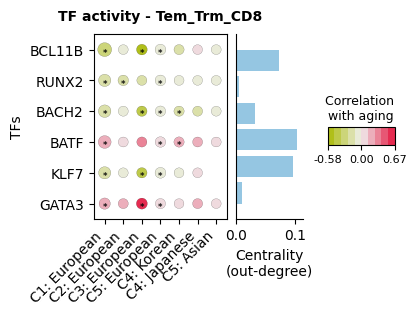

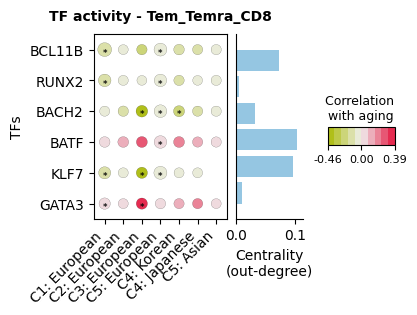

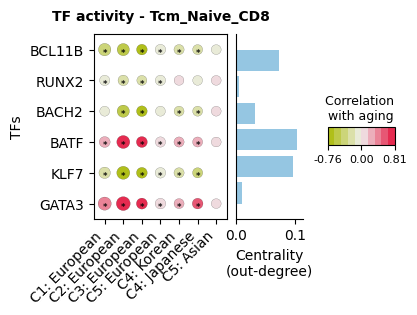

In [50]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

ttypes = ['Tem_Trm_CD8',
                'Tem_Temra_CD8',
                'Tcm_Naive_CD8']
features = ['BCL11B', 'RUNX2', 'BACH2', 'BATF', 'KLF7', 'GATA3']
type = 'bulk_minor'
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

In [2]:
case_tf = 'GATA3'  # 'TCF7' 'SATB1' 
type = 'bulk'
race = 'european'
n_top_targets = 10
selected_cell_types = ['CD8T', 'CD4T', 'NK'] #Tcm_Naive_CD8
n_panels = len(selected_cell_types)

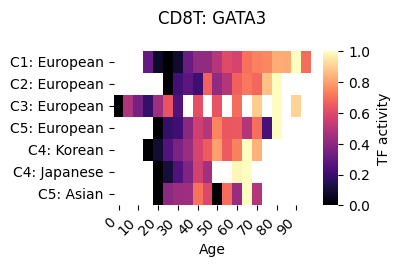

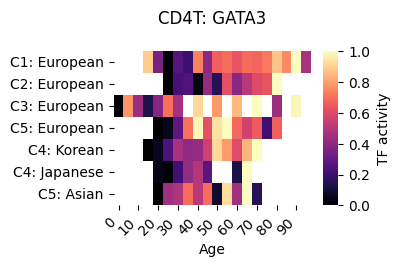

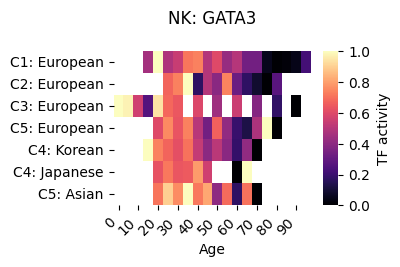

In [3]:
from ciim.src.tf_activity.plots import plot_feature_values_all_datasets

feature_type= 'tf_activity' # 'gene_expression'
for cell_type in selected_cell_types:
    plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type=feature_type, type=type, datasets=datasets_all, show_cbar=True)


In [4]:
nets_sig = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')
nets_sig = nets_sig[(nets_sig['source']==case_tf) & (nets_sig['cell_type'].isin(selected_cell_types))].copy()
n_targets = 10
if False:
    from ciim.src.tf_activity.plots import plot_net_nx
    
    for cell_type in selected_cell_types:
        net = nets_sig[(nets_sig['cell_type']==cell_type)]
        if True: # filter based on weight
            if net.shape[0]>n_targets:
                net = net.sort_values('weight', ascending=False, key=abs).head(n_targets)
        else: # targetted filter
            net = net[net['target'].isin(['FOS', 'FOSB', 'JUNB'])].copy()
        plot_net_nx(net, figsize=(4, 4))
        plt.tight_layout()
        plt.title(f'{case_tf} - {cell_type}', pad=10, fontsize=15, fontweight='bold')

In [5]:
stats_targets = retrieve_sig_stats(type, feature_type='gene_expression', race=race)

targets_store = []
for cell_type in selected_cell_types:
    net = nets_sig[nets_sig['cell_type']==cell_type]
    targets = net.sort_values('weight', ascending=False, key=abs).head(n_targets)['target'].unique()
    targets_store.append(targets)
all_targets = np.concatenate(targets_store)


def select_top_targets(cell_type, tf, n_top=30):
    net_store = []
    for dataset in datasets_all:
        net = retrieve_net(dataset, cell_type)
        net = net[(net['source']==tf) & (net['target'].isin(all_targets))].copy()
    
        #- select targets
        stats = stats_targets[(stats_targets['target'].isin(all_targets)) & (stats_targets['dataset']==dataset) & (stats_targets['cell_type']==cell_type)]
        net = net.merge(stats[['target', 'p_value_adj', 'slope']], on='target', how='left')
        net['neg_log10_adj_pval'] = -np.log10(net['p_value_adj'])
        net['dataset'] = dataset

        net_store.append(net)
    net_tf = pd.concat(net_store)
    return net_tf

net_store = []
for cell_type in selected_cell_types:
    net = select_top_targets(cell_type, case_tf, n_top=n_top_targets)
    net['cell_type'] = cell_type
    net_store.append(net)
net_tf = pd.concat(net_store)

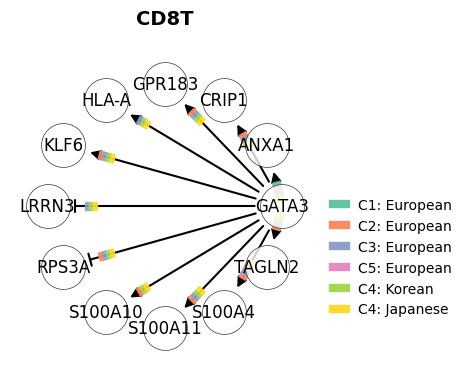

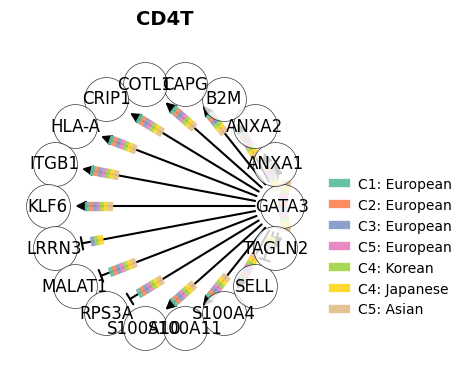

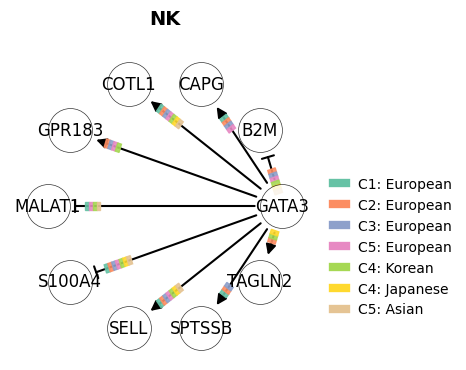

In [6]:
min_degree = 3 
draw_evidence = True
offset_evidence = .1
arc_offset = 0
figsize = (4, 4)
figsize_collectri = (4, 4)
offset_evidence_collectri = .1
for i, (cell_type) in enumerate(net_tf['cell_type'].unique()):

    net = net_tf[net_tf['cell_type'] == cell_type]
    features = net['target'].unique()

    # - keep edges with min degree
    net = net.groupby(['source', 'target']).filter(lambda x: len(x) >= min_degree)

    plot_net_nx(net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)
    plt.title(f"{cell_type}", fontsize=14, pad=20, weight='bold')
    

In [7]:
net['dataset'].unique()

array(['data1', 'data7_allTPs_jalil', 'data12', 'SLE_European',
       'data13_Korean', 'data13_Japanese', 'SLE_Asian'], dtype=object)

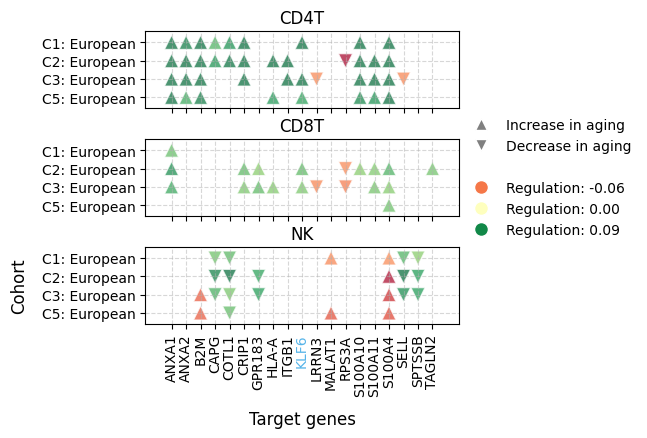

In [49]:
from ciim.src.tf_activity.plots import wrapper_flesh_out_tf_interactions, plot_tf_interactions_plus_target_stats

n_top_genes_per_dataset=10
# - select 
shared_state = net_tf.groupby(['cell_type','target'])['dataset'].nunique()
selected_tuple = shared_state[shared_state>=3].index
net_tf = net_tf.set_index(['cell_type', 'target']).loc[selected_tuple].reset_index()

n_targets = net_tf['target'].nunique()
net_tf['target'] = net_tf['target'].astype('category')
net_tf['dataset'] = pd.Categorical(net_tf['dataset'], categories=datasets_all, ordered=True)
fig, axes = plt.subplots(n_panels, 1, figsize=(n_targets*.16 +1, len(datasets_all)*.4 + 1), sharex=True)
for i, (cell_type) in enumerate(net_tf['cell_type'].unique()):
    ax = axes[i] if n_panels > 1 else axes
    if i == 1:
        show_legend = True
    else:
        show_legend = False
    net = net_tf[net_tf['cell_type'] == cell_type]   
    net = net[net['neg_log10_adj_pval'] > 1.4]
    
    # wrapper_flesh_out_tf_interactions(datasets_all, cell_type, tf=case_tf, type=type, n_top=n_top_genes_per_dataset, keep_sig_only=True, sizes=(50, 200), ax=ax, show_legend=show_legend)
    plot_tf_interactions_plus_target_stats(net.copy(), ax=ax, show_legend=show_legend, sizes=(50, 200), annotate_sig=False, annotate_targets=True)

    ax.margins(y=0.2, x=0.1)
    ax.set_title(cell_type)
    ax.set_xlabel('Target genes')
    ax.grid(True, linestyle='--', alpha=0.5)
    if i != n_panels - 1:
        ax.set_ylabel('')

plt.subplots_adjust(hspace=0.4)
# plt.suptitle(f'Targets of {tf}')

In [38]:
# tf_all = np.loadtxt(f"/vol/projects/jnourisa/prior/tf_all.csv", dtype=str)
# 'ANXA1' in tf_all

False

In [9]:
from ciim.src.tf_activity.plots import plot_net_nx, heatplot_age_trend, plot_net_nx_consensus
from ciim.src.tf_activity.helper import binarize_expression

def wrapper_plot_targets_all(nets_sig, n_top=10):
    for i, cell_type in enumerate(nets_sig['cell_type'].unique()):
        net = nets_sig[nets_sig['cell_type'] == cell_type]
        net = net.sort_values('weight', ascending=False, key=abs).head(n_top)

        # - keep those that are at least in three datasets 
        top_targets = net['target'].unique()
        
        if False: # network plot
            plot_net_nx(net, figsize=(5,4))
            # plt.title(cell_type, fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

        if True: # target trend plot
            plot_targets_expression_for_datasets(cell_type, type=type, top_targets=top_targets)
if True:
    wrapper_plot_targets_all(nets_sig, n_top=10)

ImportError: cannot import name 'plot_net_nx_consensus' from 'ciim.src.tf_activity.plots' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/plots.py)

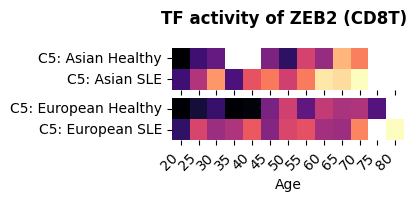

In [14]:
from ciim.src.tf_activity.plots import heatplot_age_trend
from collections import defaultdict
from ciim.src.common import surrogate_names


def format_tf_activity_for_disease_trend_plot(dataset, cell_type, tf):
    tf_acts = retrieve_feature_data(dataset, cell_type, type='bulk')
    tf_acts = tf_acts[:, tf_acts.var_names == tf]
    if tf_acts.shape[1]==0:
        return None

    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', 'disease']], left_index=True, right_index=True, how='left')
    expr['disease'] = expr['disease'].astype('category')
    expr['age'] = expr['age'].astype(int)

    # Pivot table: rows = disease, columns = age, values = expression
    expr_table = expr.pivot_table(index='disease', columns='age', values=tf)

    # Bin ages into 5-year intervals
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = defaultdict(list)

    for col in age_columns:
        bin_start = (col // 5) * 5
        age_bins[bin_start].append(col)

    # Average across bins
    binned_means = {bin_start: df[bin_ages].mean(axis=1) for bin_start, bin_ages in age_bins.items()}
    binned_df = pd.DataFrame(binned_means)

    # Sort bins by age
    binned_df = binned_df[sorted(binned_df.columns)]
    
    return binned_df


for i, cell_type in enumerate(selected_cell_types):
    fig, axes = plt.subplots(2, 1, figsize=(3, 1.2), sharey=False, sharex=True)
    
    df_store = []
    for j, dataset in enumerate(['SLE_Asian', 'SLE_European']):
        ax = axes[j]
        binned_df = format_tf_activity_for_disease_trend_plot(dataset, cell_type, tf=case_tf)
        if binned_df is None:
            continue
        binned_df.index = [f'{dataset}_{index}' for index in binned_df.index]
        
        binned_df.index = binned_df.index.astype(str)
        
        binned_df.index = [surrogate_names.get(name, name) for name in binned_df.index]
        if i == len(axes)-1:
            show_cbar = True
        else:   
            show_cbar = False
        
        heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF activity", y_label="Condition", ax=ax, show_cbar=show_cbar, shrink=1)
        if i == 0:
            ax.set_ylabel('')
        else:
            ax.set_ylabel('')
        if j == 0:
            # ax.set_title(cell_type, pad=10, fontsize=10, fontweight='bold')
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Age')
        
    plt.suptitle(f'TF activity of {case_tf} ({cell_type})', fontsize=12, fontweight='bold', y=1.2)

In [15]:
dataset = 'SLE_European'

# - plot target gene expression trend    
adata_all = retrieve_adata_bulk(dataset)
for cell_type in ['CD8T', 'CD4T', 'NK']:
    net = net_dict[cell_type]
    # - remove those with conflicting slopes across datasets
    slope_signs = net.pivot(index='target', columns='dataset', values='slope').apply(np.sign)
    mask = slope_signs.sum(axis=1).abs() == len(datasets_all)
    consistent_targets = slope_signs[mask].index
    net = net[net['target'].isin(consistent_targets)]
    # - keep those that are at least in three datasets 
    top_targets = net.groupby(['target'])['dataset'].nunique().sort_values(ascending=False)
    top_targets = top_targets[top_targets==len(datasets_all)].head(10).index

    
    # - get the expression 
    adata = adata_all[adata_all.obs['cell_type'] == cell_type]
    adata = adata[:, adata.var_names.isin(top_targets)]
    # - binarize and mean
    expr = adata.to_df()
    expr = expr.merge(adata.obs[['age', 'disease']], left_index=True, right_index=True, how='left')
    expr = expr.sort_values('age')
    expr['age_bin'] = (expr['age'].astype(int) // 5) * 5
    expr.drop(columns=['age'], inplace=True)
    mean_expr_all = expr.groupby(['age_bin', 'disease']).mean().reset_index()
    n_groups = len(mean_expr_all['disease'].unique())

    fig, axes = plt.subplots(1, n_groups, figsize=(3*n_groups, .3*len(top_targets)), sharey=False)
    for i, disease in enumerate(mean_expr_all['disease'].unique()):
        ax = axes[i]
        mean_expr = mean_expr_all[mean_expr_all['disease'] == disease].set_index('age_bin').drop(columns=['disease']).T
        if i == 0:
            # Normalize expression
            min_vals = mean_expr.min(axis=1)
            max_vals = mean_expr.max(axis=1)
            show_cbar = False
        else:
            show_cbar = True
    
        mean_expr = (mean_expr.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
        if mean_expr.shape[0] ==0 :
            print(f'No expression for {cell_type} {disease}')
            continue

        if i == 0:
            from sklearn.cluster import KMeans
            if len(mean_expr) > 2:
                kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
                clusters = kmeans.fit_predict(mean_expr.fillna(0))
                mean_expr['cluster'] = clusters
                mean_expr = mean_expr.sort_values('cluster').drop(columns=['cluster'])
            ordered_targets = mean_expr.index
        else:
            mean_expr = mean_expr.loc[ordered_targets]
        heatplot_age_trend(mean_expr, cmap='viridis', cbar_title="Gene expression", y_label="Targets", ax=ax, show_cbar=show_cbar)
        if i != 0:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        ax.set_xlabel('Age')
        ax.set_title(surrogate_names[disease], pad=10, fontsize=10, fontweight='bold')

    plt.suptitle(f"{cell_type} ({dataset.split('_')[1]})", fontsize=12, fontweight='bold', y=1.05)
# plt.tight_layout()

NameError: name 'net_dict' is not defined

In [6]:
# retrieve_feature_data(dataset, cell_type, type='bulk_minor').obs

## Sub types

In [ ]:
from ciim.src.tf_activity.plots import heatplot_age_trend

def format_tf_activity_for_minor_plot(tf, subtype, datasets):
    cell_type = mapping_minor_2_major[subtype]
    tf_acts_store = []
    for dataset in datasets:
        tf_acts = retrieve_feature_data(dataset, cell_type, type='bulk_minor')
        tf_acts = tf_acts[tf_acts.obs['Sub_CT'] == subtype]
        tf_acts = tf_acts[:, tf_acts.var_names==tf]
        tf_acts.obs['dataset'] = dataset
        tf_acts_store.append(tf_acts)
    tf_acts = ad.concat(tf_acts_store)
    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', 'dataset']], left_index=True, right_index=True, how='left')

    expr['dataset'] = expr['dataset'].astype('category')
    expr['age'] = expr['age'].astype('category')

    # - convert it to index (condition) vs columns (age)
    expr_table = expr.pivot_table(index='dataset', columns='age', values=tf)
    expr_table.columns = expr_table.columns.astype(int)
    # - binarize the age
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = {}
    for col in age_columns:
        bin_start = (col // 5) * 5  # Determine the bin start
        if bin_start not in age_bins:
            age_bins[bin_start] = []  # Initialize the list if the bin is not yet in the dictionary
        age_bins[bin_start].append(col)
    binned_means = {}
    for bin_start, bin_ages in age_bins.items():
        binned_means[bin_start] = df[bin_ages].mean(axis=1)

    expr_mean = pd.DataFrame(binned_means)
    min_vals = expr_mean.min(axis=1)
    max_vals = expr_mean.max(axis=1)
    expr_mean = (expr_mean.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
    return expr_mean

#     # - binarize 
#     if True: 
#         expr = adata.to_df()
#         expr = expr.merge(adata.obs[['age']], left_index=True, right_index=True, how='left').set_index('age')
#         # expr = expr[expr.index>10]
#         expr.sort_index(inplace=True)
#         expr['age_bin'] = (expr.index.astype(int) // 5) * 5
#         expr_mean = expr.groupby('age_bin').mean().T
#     # Normalize expression
#     min_vals = expr_mean.min(axis=1)
#     max_vals = expr_mean.max(axis=1)
#     expr_mean = (expr_mean.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
#     return expr_mean

for j, cell_type in enumerate(['CD8T', 'CD4T', 'NK']):
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(3*len(subtypes), 1.5), sharey=True)

    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        binned_df = format_tf_activity_for_minor_plot(case_tf, subtype=subtype, datasets=datasets_all)

        binned_df.index = binned_df.index.astype(str)
        binned_df = binned_df.reindex(datasets_all)
        binned_df.index = binned_df.index.map(lambda name: surrogate_names.get(name, name))

        if i == len(axes)-1:
            show_cbar = True
        else:   
            show_cbar = False
        
        heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF activity", y_label="Condition", ax=ax, show_cbar=show_cbar, shrink=1)
        if i == 0:
            ax.set_ylabel('Cell type')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('Age')
        ax.set_title(subtype, pad=10, fontsize=10, fontweight='bold')
    plt.suptitle(f'TF activity trend of {case_tf} ({cell_type})', fontsize=12, fontweight='bold', y=1.3)